In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math

import jax

jax.config.update("jax_enable_x64", True)
# Set the default device to CPU
jax.config.update("jax_default_device", jax.devices("cpu")[0])
import jax.numpy as jnp

from tensorrsvd import ho_rsvd

from optimization_core import (
    build_jsa_grid,
    scaled_gaussian_jsa_vectorized_rsvd,
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# Parameters for the multivariate normal distribution
n = 50  # Number of points in the frequency grid nxnxn
d = 3  # Dimensionality of the problem
mean = jnp.zeros(d)  # Mean
x_lim = 4  # Limits in x and y ax0is for plotting
r = -0.49  # Correlation coefficient

In [3]:
# ---------------------------------------------------------
# 2. Build JSA grid and initial mode
# ---------------------------------------------------------
_, jsa = build_jsa_grid(n=n, mean=mean, rho=r, x_lim=x_lim)

In [4]:
jsa_flat = jnp.reshape(jsa, (n, n ** (d - 1)))
u, s, vt = jax.scipy.linalg.svd(jsa_flat, full_matrices=False)

In [5]:
axis = jnp.linspace(-x_lim, x_lim, n)
grid = jnp.meshgrid(*([axis] * d), indexing="ij")
points = jnp.stack([g.ravel() for g in grid], axis=1)

In [6]:
f = scaled_gaussian_jsa_vectorized_rsvd(r=r, mean=mean, x_lim=x_lim)

In [7]:
rank = 20
U_list, S_list = ho_rsvd(
    tensor=f,
    tensor_shape=(n,) * d,
    dtype=jnp.float64,
    rank=rank,
    num_oversamples=10,
    num_power_iterations=2,
    num_idxs=d,
    backend="jax",
)

In [8]:
s_norm = s / jnp.linalg.norm(s)
S_list_norm = S_list[0] / jnp.linalg.norm(S_list[0])

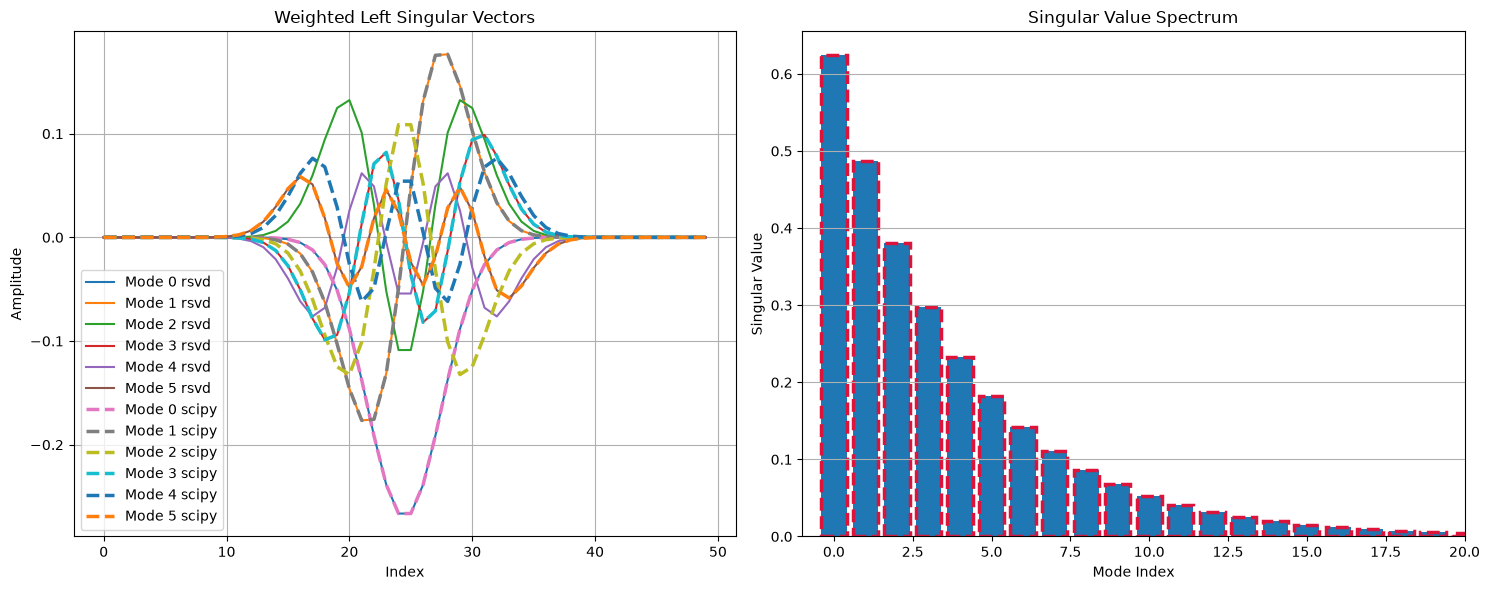

In [9]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

n_modes = 6  # Number of modes to plot
for i in range(n_modes):
    axes[0].plot(S_list_norm[i] * U_list[0][:, i], label=f"Mode {i} rsvd")
for i in range(n_modes):
    axes[0].plot(
        s_norm[i] * u[:, i], label=f"Mode {i} scipy", linestyle="--", linewidth=2.5
    )

axes[0].set_xlabel("Index")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Weighted Left Singular Vectors")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Singular values (Scree plot)
axes[1].bar(jnp.arange(len(S_list[0])), S_list_norm, label="rsvd")
axes[1].bar(
    jnp.arange(len(s)),
    s_norm,
    label="scipy",
    linestyle="--",
    linewidth=2.5,
    color="none",
    edgecolor="crimson",
)
axes[1].set_xlim(-1, 20)
axes[1].set_xlabel("Mode Index")
axes[1].set_ylabel("Singular Value")
axes[1].set_title("Singular Value Spectrum")
axes[1].grid(axis="y")

plt.tight_layout()  # Prevents overlapping labels
plt.show()

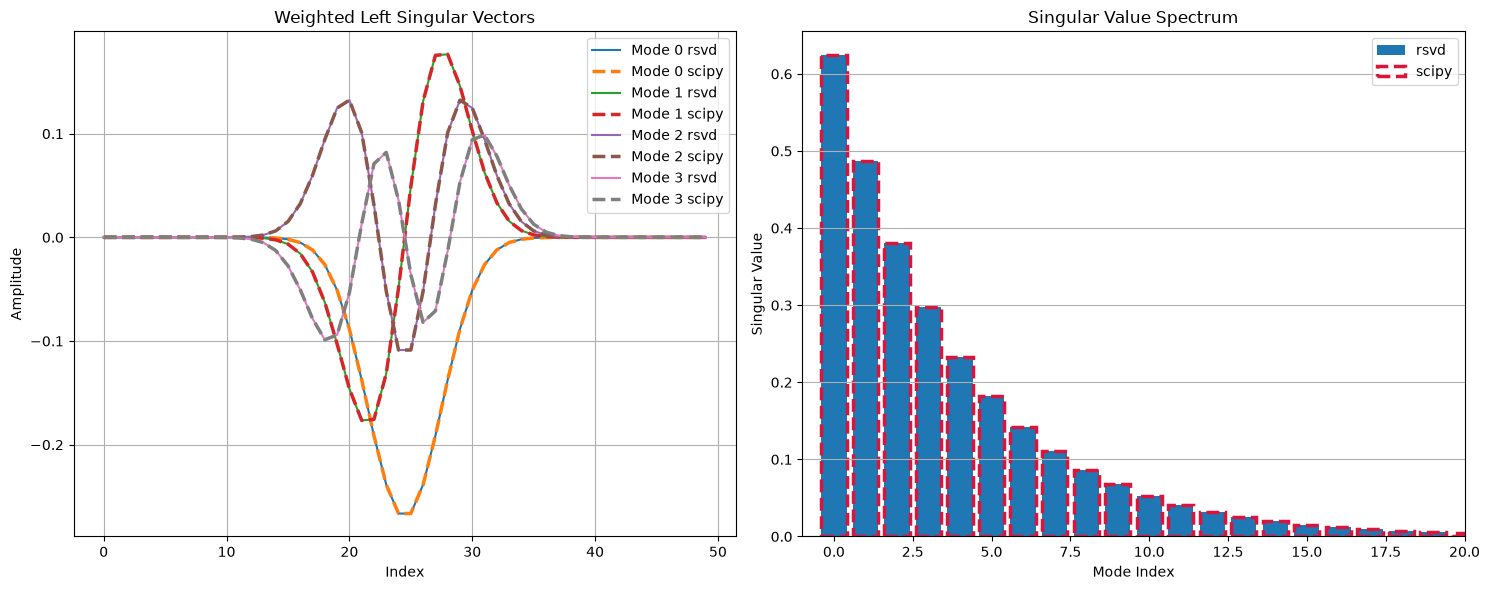

In [12]:
# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

n_modes = 1  # Number of modes to plot
axes[0].plot(S_list_norm[0] * U_list[0][:, 0], label=f"Mode {0} rsvd")
axes[0].plot(
    s_norm[0] * u[:, 0], label=f"Mode {0} scipy", linestyle="--", linewidth=2.5
)
axes[0].plot(S_list_norm[1] * U_list[0][:, 1], label=f"Mode {1} rsvd")
axes[0].plot(
    s_norm[1] * u[:, 1], label=f"Mode {1} scipy", linestyle="--", linewidth=2.5
)
axes[0].plot(S_list_norm[2] * U_list[0][:, 2], label=f"Mode {2} rsvd")
axes[0].plot(
    -1 * s_norm[2] * u[:, 2], label=f"Mode {2} scipy", linestyle="--", linewidth=2.5
)
axes[0].plot(S_list_norm[3] * U_list[0][:, 3], label=f"Mode {3} rsvd")
axes[0].plot(
    s_norm[3] * u[:, 3], label=f"Mode {3} scipy", linestyle="--", linewidth=2.5
)


axes[0].set_xlabel("Index")
axes[0].set_ylabel("Amplitude")
axes[0].set_title("Weighted Left Singular Vectors")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Singular values (Scree plot)
axes[1].bar(jnp.arange(len(S_list[0])), S_list_norm, label="rsvd")
axes[1].bar(
    jnp.arange(len(s)),
    s_norm,
    label="scipy",
    linestyle="--",
    linewidth=2.5,
    color="none",
    edgecolor="crimson",
)
axes[1].set_xlim(-1, 20)
axes[1].set_xlabel("Mode Index")
axes[1].set_ylabel("Singular Value")
axes[1].set_title("Singular Value Spectrum")
axes[1].grid(axis="y")
axes[1].legend()

plt.tight_layout()  # Prevents overlapping labels
plt.show()

In [13]:
def plot_2d_projection(jsa_vals):
    """
    Plot a 2D projection of a multivariate PDF f by varying two coordinates
    and fixing the rest at their mean values.

    f: vectorized PDF function created by make_mvn_pdf_vectorized
    mean: (d,) array
    idx: tuple (i,j) selecting which coordinates to vary
    n: grid resolution
    lim: plot range [-lim, lim]
    """
    d = jnp.ndim(jsa_vals)

    jsa_vals /= jnp.linalg.norm(jsa_vals)

    # Square the JSA
    jsa_sq = jsa_vals**2

    # Sum over axes 2..d-1
    axes_to_sum = tuple(range(2, d))
    S = jnp.sum(jsa_sq, axis=axes_to_sum)

    plt.figure(figsize=(6, 5))

    plt.imshow(S, origin="lower", cmap="viridis", alpha=0.85)
    # plt.contour(axis, axis, S, colors="white", linewidths=0.7)

    plt.colorbar(label="Intensity")
    plt.xlabel(r"i")
    plt.ylabel(r"j")
    plt.title("2D Projection of Joint spectral intensity")

    plt.show()

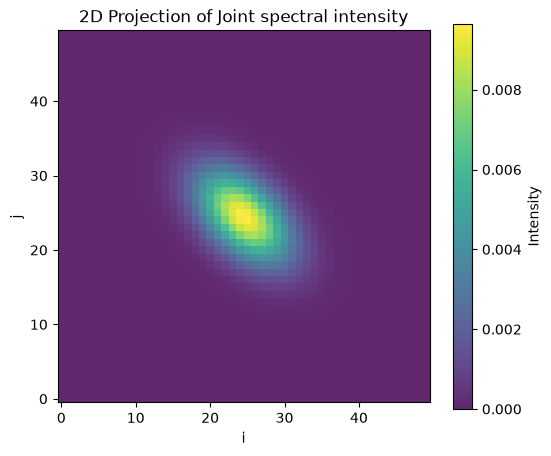

In [14]:
plot_2d_projection(jsa)

In [15]:
axis01 = jnp.linspace(0, 1, n)
grid01 = jnp.meshgrid(*([axis01] * d), indexing="ij")

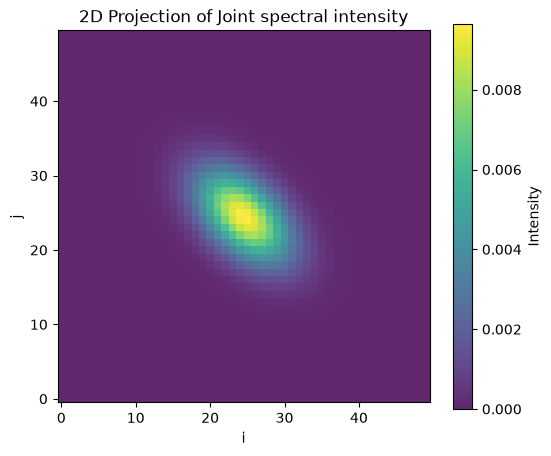

In [16]:
plot_2d_projection(f(*grid01))

In [17]:
diff = jsa / jnp.linalg.norm(jsa) - f(*grid01) / jnp.linalg.norm(f(*grid01))
print("max abs diff:", jnp.max(jnp.abs(diff)))
print("max rel diff:", jnp.max(jnp.abs(diff) / (jnp.abs(jsa) + 1e-30)))
print("dtype jsa:", jsa.dtype, " dtype f:", f(*grid01).dtype)

max abs diff: 9.71445146547012e-17
max rel diff: 7.100562279041992e-14
dtype jsa: float64  dtype f: float64
